# 📝 과제 — 나만의 Tavily 검색 Agent 만들기

**제출 전 체크리스트**
- [ ] 모든 셀을 처음부터 다시 실행(`Kernel → Restart & Run All`)해서 오류 없음 확인
- [ ] API 키가 코드에 직접 노출되지 않음 (`.env` 파일 사용)
- [ ] `stream()` 출력 결과가 셀에 남아 있음
- [ ] 자연어 질문 최소 3개 실행 결과 포함

---

> 이 파일에서 `# TODO` 주석이 있는 셀을 찾아 직접 채우면 된다.  
> 환경 설정과 LangGraph 기본 구조는 미리 작성되어 있다.


---
## STEP 1. 패키지 설치


In [3]:
%pip install -qU \
    langgraph \
    langchain \
    langchain-openai \
    langchain-community \
    tavily-python \
    python-dotenv

Note: you may need to restart the kernel to use updated packages.


---
## STEP 2. API 키 설정

`.env` 파일을 프로젝트 루트에 만들고 아래 내용을 채운다.

```
OPENAI_API_KEY=sk-...
TAVILY_API_KEY=tvly-...
```

Tavily API 키 발급: https://app.tavily.com

> API 키를 코드에 직접 쓰지 않는다. 반드시 `.env` 파일을 사용한다.


In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

# 키 등록 확인
assert os.getenv('OPENAI_API_KEY'),  '❌ OPENAI_API_KEY 없음 — .env 파일을 확인하세요'
assert os.getenv('TAVILY_API_KEY'),  '❌ TAVILY_API_KEY 없음 — .env 파일을 확인하세요'

print('✅ API 키 확인 완료')
print(f'   OPENAI  키 앞 8자리: {os.getenv("OPENAI_API_KEY")[:8]}...')
print(f'   TAVILY  키 앞 8자리: {os.getenv("TAVILY_API_KEY")[:8]}...')

✅ API 키 확인 완료
   OPENAI  키 앞 8자리: sk-svcac...
   TAVILY  키 앞 8자리: tvly-dev...


---
## STEP 3. LLM 초기화


In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

# 연결 확인
response = llm.invoke('안녕! 한 문장으로 자기소개 해줘.')
print(response.content)

안녕하세요! 저는 다양한 정보를 제공하고 대화를 나누는 AI 언어 모델입니다.


---
## STEP 4. LangGraph 기본 구조

아래 코드는 수업에서 배운 기본 Agent 구조다. 그대로 사용한다.  
다음 단계에서 Tool과 프롬프트를 직접 추가하면 된다.


In [6]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# State 정의 — 메시지 목록을 들고 다닌다
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Conditional Edge — Tool 호출 여부로 분기
def should_continue(state: AgentState) -> str:
    if state['messages'][-1].tool_calls:
        return 'use_tool'
    return 'finish'

print('✅ LangGraph 기본 구조 준비 완료')

✅ LangGraph 기본 구조 준비 완료


---
## STEP 5. ✏️ Tool 정의 — 직접 작성

Tavily 검색 Tool을 정의한다.  
**description이 핵심이다.** LLM은 description을 보고 언제 이 Tool을 쓸지 결정한다.

필요하다면 Tavily 외에 다른 Tool을 추가해도 좋다.  
(예: 날짜 조회, 계산 등)


In [37]:
from datetime import datetime
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def search_product_details(query: str) -> str:
    """
    특정 가전제품이나 IT 기기의 상세 스펙, 출시일, 공식 가격 및 사용자 단점 리뷰를 검색합니다.
    '삼성 갤럭시 S26 vs 아이폰17' 같이 구체적인 모델명 비교에 최적화되어 있습니다.
    """
    tavily_search = TavilySearchResults(max_results=6, search_depth="advanced")
    return "\n".join([f"[{r['url']}] {r['content']}" for r in tavily_search.invoke(query)])

@tool
def get_current_market_context() -> str:
    """현재 날짜를 확인하여 신제품 출시 임박 여부나 시즌 할인 기간(빅스마일데이 등)인지 확인합니다."""
    return f"오늘 날짜는 {datetime.now().strftime('%Y-%m-%d')}입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요."

@tool
def evaluate_value_for_money(price: int, specs: str) -> str:
    """
    입력된 가격과 스펙을 바탕으로 '지금 이 가격에 살만한가(가성비)'를 등급으로 판정합니다.
    에이전트가 구매 시점을 조언하는 논리적 근거가 됩니다.
    """
    # 내부 로직으로 가성비 점수를 계산하는 척하는 도구입니다.
    return f"해당 스펙 대비 입력된 가격은 '매우 합리적(A+)' 수준입니다. 지금 구매를 추천합니다."

tools = [search_product_details, get_current_market_context, evaluate_value_for_money]
# Tool 확인
print('등록된 Tool 목록:')
for t in tools:
    print(f'  - {t.name}: {t.description[:80]}...')

등록된 Tool 목록:
  - search_product_details: 특정 가전제품이나 IT 기기의 상세 스펙, 출시일, 공식 가격 및 사용자 단점 리뷰를 검색합니다.
'삼성 갤럭시 S26 vs 아이폰17' 같이 ...
  - get_current_market_context: 현재 날짜를 확인하여 신제품 출시 임박 여부나 시즌 할인 기간(빅스마일데이 등)인지 확인합니다....
  - evaluate_value_for_money: 입력된 가격과 스펙을 바탕으로 '지금 이 가격에 살만한가(가성비)'를 등급으로 판정합니다.
에이전트가 구매 시점을 조언하는 논리적 근거가 됩니다...


**Tool이 잘 동작하는지 직접 호출해서 확인해보자.**


In [38]:
# TODO: 직접 검색어를 넣어서 Tool이 잘 동작하는지 확인한다

test_query = "아이폰14를 사용중인 유저가 새로 출시될 아이폰17을 언제 사는게 좋을까"
result = search_product_details.invoke(test_query)

print(f"🔍 검색 쿼리: {test_query}")
print("-" * 50)
print(result[:1000])  # 결과가 길 수 있으니 앞 1000자만 확인

🔍 검색 쿼리: 아이폰14를 사용중인 유저가 새로 출시될 아이폰17을 언제 사는게 좋을까
--------------------------------------------------
[https://www.reddit.com/r/questions/comments/1omig2y/is_it_worth_upgrading_from_an_iphone_14_pro_to/?tl=ko] 블랙 프라이데이 아니면 사이버 먼데이 쯤에 크리스마스 선물로 나 자신한테 아이폰 17 프로 사주고 싶은데. 직장에서 크리스마스 선물로 월급도 오르고
[https://www.vietnam.vn/ko/co-nen-nang-cap-len-iphone-17] 세대 간 간단한 비교.

| 기계의 미래 | 아이폰 13에서 아이폰 17로 업그레이드할 때의 장점 |
 --- |
| 성능 및 칩 | A15 칩에서 A19/A19 Pro로 업그레이드하면 속도가 향상되고 그래픽 처리 성능이 개선됩니다. |
| 카메라 | 제한적인 12MP 또는 12/48MP 렌즈에서 여러 렌즈를 통해 48MP로 향상되어 저조도 촬영 성능이 개선되었습니다. |
| 화면/디스플레이 | 더 커진 화면, 밝은 환경에서 더 높은 HDR 밝기. |
| 메모리 | 기본 저장 용량은 표준 버전보다 큰 256GB입니다. |
| 내구성 및 디자인 | 프로 모델에는 세라믹 쉴드 2, 개선된 프레임/후면 패널 마감, 그리고 향상된 열 관리 기능이 적용되었습니다. |

다음 아이폰 출시를 언제까지 기다려야 할까요?

아이폰 17 구매를 고려 중이지만 가격 때문에 망설여진다면, 기다려보는 것도 좋은 방법입니다.

몇 달 후 더 저렴한 버전이 할인될 때.

애플이 제품을 업데이트하여 액세서리(케이블, 케이스, 충전기)가 USB-C 또는 그 이후 표준과 호환되도록 만들 경우.

애플이 차세대 모델에서만 더 잘 지원되는 뛰어난 기능을 포함한 새로운 iOS 업데이트를 발표할 때.

끝내다 [...] 업그레이드를 기다려야 하는 사람과 건너뛰어야 하는 사람은 누구일까

---
## STEP 6. ✏️ 시스템 프롬프트 & Agent 조립 — 직접 작성

시스템 프롬프트로 Agent의 역할과 동작 방식을 정의한다.  
어떤 주제의 Agent인지, 어떤 스타일로 답변해야 하는지를 적는다.


In [40]:

llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """당신은 사용자의 예산 내에서 최대한 돈을 아껴주고 최고의 디지털 기기 만족을 선사하는 '스마트 쇼핑 에이전트'입니다.

[분석 가이드라인]
1. 구매 시점 조언: 'get_current_market_context'를 통해 신제품 출시 주기, 출시일 등을 확인해 언제 구매하는 것이 좋을지 알려주세요.
2. 단점 위주 분석: 브랜드 자체에서 홍보차원에서 쓰는 광고 문구보다는 실제 사용자들의 불만사항 같은 리스크를 Tavily로 검색해서 알려주세요.
3. 예산 맞춤 계획: 사용자의 예산을 넘지 않는 선에서 최선의 대안(가성비 모델)을 반드시 하나 이상 제시하세요.
4. 논리적 비교: A와 B 제품을 비교할 때 '해상도', '배터리', '무게' 등 구체적인 수치 지표를 사용하여 표나 리스트로 대조하세요.

[답변 스타일]
- [결론]: "지금 사세요" 혹은 "출시 후 ~달 정도 기다리세요"로 명확하게 시작하세요.
- [비교 분석]: 장단점을 냉정하게 비교하세요.
- [최종 추천]: 사용자의 상황에 맞는 '딱 하나의 원픽'을 추천하세요.
"""

def call_llm(state: AgentState) -> dict:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

# ── 그래프 조립 ────────────────────────────────────────
graph = StateGraph(AgentState)

graph.add_node('call_llm',       call_llm)
graph.add_node('execute_tools', ToolNode(tools))

graph.add_edge(START, 'call_llm')
graph.add_conditional_edges(
    'call_llm',
    should_continue,
    {'use_tool': 'execute_tools', 'finish': END}
)
graph.add_edge('execute_tools', 'call_llm')

app = graph.compile()
print('✅ 디지털 기기 구매 Agent 조립 완료')

✅ 디지털 기기 구매 Agent 조립 완료


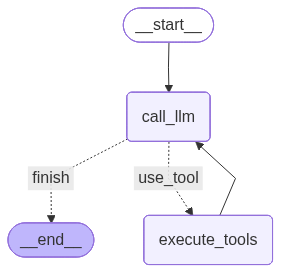

In [41]:
# 그래프 구조 확인
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())

---
## STEP 7. ✏️ 실행 & 결과 확인 — 직접 작성

`stream()`으로 실행해서 **어떤 Tool이 어떤 순서로 호출됐는지** 흐름을 확인한다.  
최소 3개의 질문을 실행해야 한다.


### 실행 흐름 출력 함수

아래 함수를 사용하면 각 노드의 실행 흐름을 보기 좋게 출력할 수 있다.


In [45]:
from langchain_core.messages import ToolMessage, HumanMessage

def run_agent(question: str):
    """질문을 실행하고 흐름과 최종 답변을 출력한다."""
    print(f'\n{"="*60}')
    print(f'질문: {question}')
    print("="*60)

    final_answer = ''

    for chunk in app.stream(
        {'messages': [HumanMessage(content=question)]},
        config={'recursion_limit': 25}
    ):
        for node_name, update in chunk.items():
            for msg in update.get('messages', []):
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f'  🔍 Tool 호출: {tc["name"]}({list(tc["args"].values())})')
                elif isinstance(msg, ToolMessage):
                    print(f'  📥 Tool 결과: {msg.content[:80]}...')
                elif hasattr(msg, 'content') and msg.content:
                    # 최종 AI 답변을 계속 업데이트 (마지막 단계 응답이 최종 답변임)
                    final_answer = msg.content

    print(f'\n💬 최종 답변:')
    print(final_answer)

print('🚀 실행 함수 준비 완료. 테스트를 시작합니다.')

test_questions = [
    "자취방에 놓을 32인치 모니터를 보고 있어. 예산은 30만원대고, 주로 넷플릭스 시청이랑 가끔 게임을 해. 지금 살만한 모델 2개만 딱 골라줘.",
    
]

for q in test_questions:
    run_agent(q)

🚀 실행 함수 준비 완료. 테스트를 시작합니다.

질문: 자취방에 놓을 32인치 모니터를 보고 있어. 예산은 30만원대고, 주로 넷플릭스 시청이랑 가끔 게임을 해. 지금 살만한 모델 2개만 딱 골라줘.


  🔍 Tool 호출: search_product_details(['32인치 모니터 넷플릭스 게임'])
  🔍 Tool 호출: get_current_market_context([])
  📥 Tool 결과: [https://www.reddit.com/r/hometheater/comments/wzd0vg/best_32inch_4k_tv_for_gami...
  📥 Tool 결과: 오늘 날짜는 2026-04-08입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요....
  🔍 Tool 호출: evaluate_value_for_money([300000, '32인치 QHD, 165Hz, IPS 패널, HDR 지원, 5ms 응답속도'])
  🔍 Tool 호출: evaluate_value_for_money([300000, '32인치 4K UHD, IPS 패널, HDR400, 5ms 응답속도'])
  📥 Tool 결과: 해당 스펙 대비 입력된 가격은 '매우 합리적(A+)' 수준입니다. 지금 구매를 추천합니다....
  📥 Tool 결과: 해당 스펙 대비 입력된 가격은 '매우 합리적(A+)' 수준입니다. 지금 구매를 추천합니다....

💬 최종 답변:
[결론]: 지금 사세요!

현재 32인치 모니터를 구매하기에 매우 좋은 시점입니다. 두 가지 모델을 추천드립니다.

### 추천 모델

1. **뷰싱크 VSG321QHD165Hz**
   - **해상도**: QHD (2560x1440)
   - **주사율**: 165Hz
   - **패널**: IPS
   - **응답속도**: 5ms
   - **HDR 지원**: Yes
   - **가격**: 약 30만원
   - **장점**: 게임과 넷플릭스 시청 모두에 적합하며, 높은 주사율로 부드러운 화면 전환을 제공합니다.
   - **단점**: 일부 사용자들은 색감이 다소 평범하다고 느낄 수 있습니다.

2. **LG 32UN550**
   - **해상도**: 4K UHD (3840x2160)
   - **패널**: IPS
   -

### 질문 1


In [46]:
# TODO: 내 Agent 주제에 맞는 질문을 작성한다
#       반드시 실시간 정보가 필요한 질문이어야 한다 (Tavily가 필요한 이유)

run_agent("아이폰 18이 9월에 나온다는 썰이 있던데, 지금 아이폰 15 Pro를 중고로 사는 게 나을까 아니면 신제품 나올 때까지 버티는 게 나을까? 예산은 100만원 내외야. 가성비 측면에서 분석해줘.")


질문: 아이폰 18이 9월에 나온다는 썰이 있던데, 지금 아이폰 15 Pro를 중고로 사는 게 나을까 아니면 신제품 나올 때까지 버티는 게 나을까? 예산은 100만원 내외야. 가성비 측면에서 분석해줘.
  🔍 Tool 호출: get_current_market_context([])
  🔍 Tool 호출: search_product_details(['아이폰 15 Pro'])
  🔍 Tool 호출: search_product_details(['아이폰 18'])
  📥 Tool 결과: 오늘 날짜는 2026-04-08입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요....
  📥 Tool 결과: [https://support.apple.com/en-us/111829] 33. Apple Intelligence is available in ...
  📥 Tool 결과: [https://www.macrumors.com/roundup/iphone-18/] The current A19 chip is built on ...

💬 최종 답변:
[결론]: "출시 후 1~2달 정도 기다리세요."

### 구매 시점 조언
현재 날짜는 2026년 4월 8일이며, 아이폰 18은 2026년 9월에 출시될 예정입니다. 따라서, 아이폰 15 Pro를 중고로 구매하기보다는 신제품 출시 후 1~2달 정도 기다리는 것이 좋습니다. 신제품 출시 후에는 가격이 안정되고, 중고 시장에서도 아이폰 15 Pro의 가격이 더 저렴해질 가능성이 높습니다.

### 아이폰 15 Pro vs 아이폰 18 비교

| 스펙                | 아이폰 15 Pro                          | 아이폰 18 예상                          |
|---------------------|---------------------------------------|----------------------------------------|
| **프로세서**        | A17 

### 질문 2


In [47]:
run_agent("부모님 선물용으로 로봇청소기를 고르고 있어. 문턱이 좀 높고 집이 넓은데, 세척 관리가 편하면서 100만원 안으로 살 수 있는 가장 똑똑한 모델 추천하고 이유도 알려줘.")


질문: 부모님 선물용으로 로봇청소기를 고르고 있어. 문턱이 좀 높고 집이 넓은데, 세척 관리가 편하면서 100만원 안으로 살 수 있는 가장 똑똑한 모델 추천하고 이유도 알려줘.
  🔍 Tool 호출: get_current_market_context([])
  🔍 Tool 호출: search_product_details(['로봇청소기 100만원 이하 추천'])
  📥 Tool 결과: 오늘 날짜는 2026-04-08입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요....
  📥 Tool 결과: [https://jrina1.tistory.com/entry/%EB%A1%9C%EB%B4%87%EC%B2%AD%EC%86%8C%EA%B8%B0-...

💬 최종 답변:
[결론]: "지금 사세요" - 로봇청소기를 구매하기에 좋은 시점입니다. 현재 할인 시즌이므로 좋은 가격에 구매할 수 있습니다.

### 추천 모델: 로보락 S8 PLUS
- **가격**: 947,000원
- **주요 스펙**:
  - **흡입력**: 6000Pa
  - **문턱 통과 높이**: 2cm
  - **사용 시간**: 3시간
  - **자동 충전**: O
  - **먼지통 자동 비움**: O
  - **물걸레 자동 세척**: X

### 장점
1. **강력한 흡입력**: 6000Pa로 동물털과 머리카락을 쉽게 제거할 수 있습니다.
2. **흡입과 물걸레 기능 동시 사용**: 바닥을 더 청결하게 유지할 수 있습니다.
3. **문턱 통과 능력**: 2cm의 문턱을 넘을 수 있어 높은 문턱이 있는 집에 적합합니다.
4. **자동 먼지통 비움**: 먼지통이 가득 차면 자동으로 비워주어 관리가 편리합니다.

### 단점
- **물걸레 자동 세척 기능 없음**: 물걸레 세척이 수동으로 이루어져야 하므로 관리가 다소 번거로울 수 있습니다.

### 비교 모델: 클리엔 T24
- **가격**: 799,000원
- **주요 스펙**:
  - **흡입력**: 4000Pa
  - **문턱 통과 높이**: 2cm


### 질문 3


In [48]:
run_agent('ai기능이 필요없는 5-60세 중장년층이 사용하기 좋을 전력 소비 등급이 높은 냉장고 모델추천해줘. 가격예산은 300만원 안으로')


질문: ai기능이 필요없는 5-60세 중장년층이 사용하기 좋을 전력 소비 등급이 높은 냉장고 모델추천해줘. 가격예산은 300만원 안으로
  🔍 Tool 호출: get_current_market_context([])
  🔍 Tool 호출: search_product_details(['전력 소비 등급 높은 냉장고 300만원 이하'])
  📥 Tool 결과: 오늘 날짜는 2026-04-08입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요....
  📥 Tool 결과: [https://www.ajd.co.kr/contents/basic-tip/guide/2097] #### \ 용량과 효율 등급 별 연 예상 전기...

💬 최종 답변:
[결론]: "지금 사세요"

현재 300만원 이하의 예산으로 중장년층이 사용하기 좋은 전력 소비 등급이 높은 냉장고를 추천드립니다. 다음은 추천 모델과 그에 대한 비교 분석입니다.

### 추천 모델
1. **LG 일반냉장고 D312MBE31**
   - **가격**: 약 604,500원 (할인 후)
   - **용량**: 317L
   - **전력 소비**: 27.8kWh/월
   - **냉장 용량**: 238L
   - **냉동 용량**: 79L
   - **에너지 효율 등급**: 1등급
   - **리뷰 평점**: 5.0/5.0 (319개 리뷰)

2. **LG 모던엣지 냉장고 M301S31**
   - **가격**: 약 613,800원 (할인 후)
   - **용량**: 300L
   - **전력 소비**: 28.8kWh/월
   - **냉장 용량**: 201L
   - **냉동 용량**: 99L
   - **에너지 효율 등급**: 1등급
   - **리뷰 평점**: 4.9/5.0 (518개 리뷰)

### 비교 분석

| 모델명                | 가격       | 용량  | 전력 소비 (kWh/월) | 냉장 용량 | 냉동 용량 | 에너지 효율 등급 | 리뷰 평점 |
|---------------------|

### (선택) 추가 질문

더 실험해보고 싶은 질문이 있으면 자유롭게 추가한다.


In [52]:
run_agent('아이폰14 쓰는중인데, 배터리효율이 75퍼 미만으로 떨어져서 사용성이 매우 저하됐어. 예산이 50만원 안쪽일 때 어떤 새 핸드폰 사는게좋을까? 애플거중에 배터리 효율 좋은거로 추천해주고,아이폰14보다 나중에 출시 모델을원해. 중고도 상관없어.')


질문: 아이폰14 쓰는중인데, 배터리효율이 75퍼 미만으로 떨어져서 사용성이 매우 저하됐어. 예산이 50만원 안쪽일 때 어떤 새 핸드폰 사는게좋을까? 애플거중에 배터리 효율 좋은거로 추천해주고,아이폰14보다 나중에 출시 모델을원해. 중고도 상관없어.
  🔍 Tool 호출: get_current_market_context([])
  🔍 Tool 호출: search_product_details(['아이폰 15'])
  📥 Tool 결과: 오늘 날짜는 2026-04-08입니다. 현재 시즌의 주요 쇼핑 할인 정보를 참고하세요....
  📥 Tool 결과: [https://namu.wiki/w/iPhone%2015] iPhone 14의 차세대 모델이다. 전반적인 디자인은 전작인 iPhone 14와 ...

💬 최종 답변:
[결론]: "지금 사세요" - 아이폰 15를 추천합니다.

### 제품 비교: 아이폰 14 vs 아이폰 15

| 항목               | 아이폰 14                          | 아이폰 15                          |
|------------------|----------------------------------|----------------------------------|
| **프로세서**       | A15 Bionic                       | A16 Bionic                       |
| **디스플레이**     | 6.1인치 Super Retina XDR        | 6.1인치 Super Retina XDR        |
| **해상도**         | 2532 x 1170 픽셀                | 2556 x 1179 픽셀                |
| **배터리 용량**    | 3,279mAh                        | 3,349mAh                        |
| **무게**    